<a href="https://colab.research.google.com/github/adarsh06-zen/Online-Retail/blob/main/Online_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df=pd.read_excel('/content/Online Retail.xlsx')

In [5]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


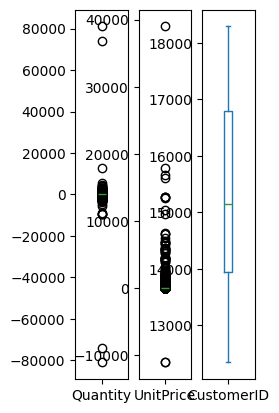

In [9]:
df.plot(kind='box',subplots=True,layout=(1,8))
plt.show()

In [10]:
#STEP 4 – Data Cleaning

#Remove product returns (negative quantity)
df = df[df["Quantity"] > 0]


In [11]:
# Remove zero price rows
df = df[df["UnitPrice"] > 0]

In [12]:


# Remove missing product names
df = df.dropna(subset=["Description"])

In [13]:
# Convert InvoiceDate to proper date format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [14]:
# STEP 5 – Create Revenue Column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

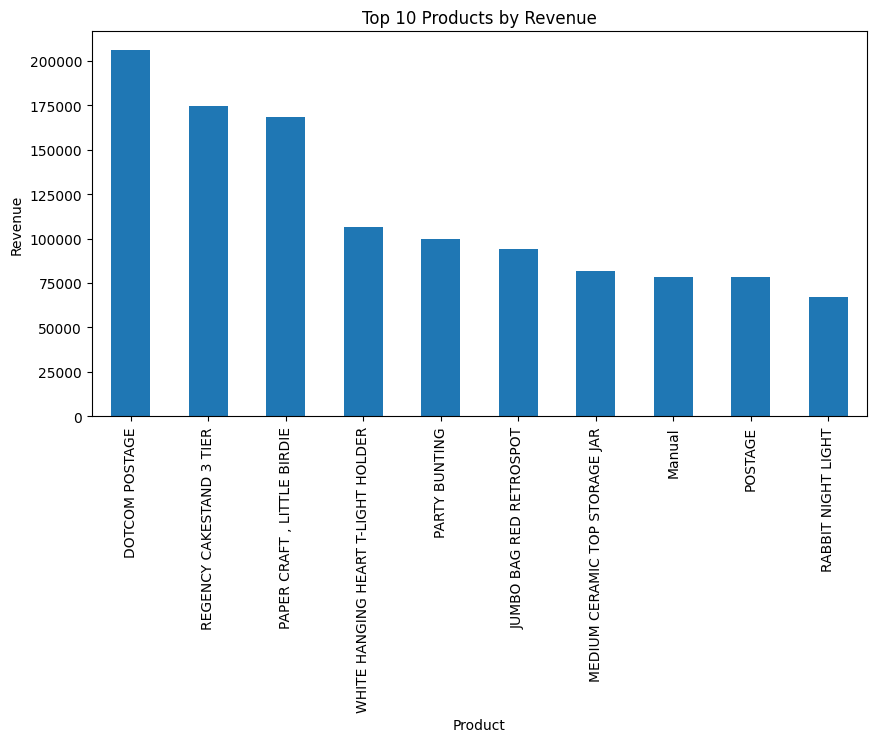

In [17]:
# STEP 6 – Top 10 Products by Revenue
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.show()

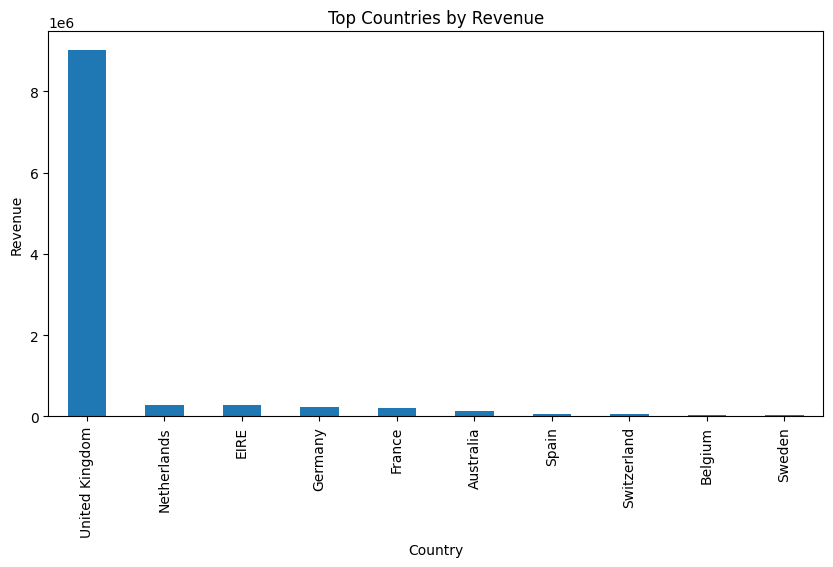

In [22]:
# STEP 7 – Country-wise Sales Analysis
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

country_sales.plot(kind="bar")

plt.title("Top Countries by Revenue")

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.show()

# Insight

# Which country contributes most sales.

In [25]:
# STEP 8 – Monthly Sales Trend
# Create month column
df["Month"] = df["InvoiceDate"].dt.to_period("M")


In [27]:
# Calculate monthly revenue:
monthly_sales = df.groupby("Month")["Revenue"].sum()


In [28]:
# !file /content/Online\ Retail.xlsx

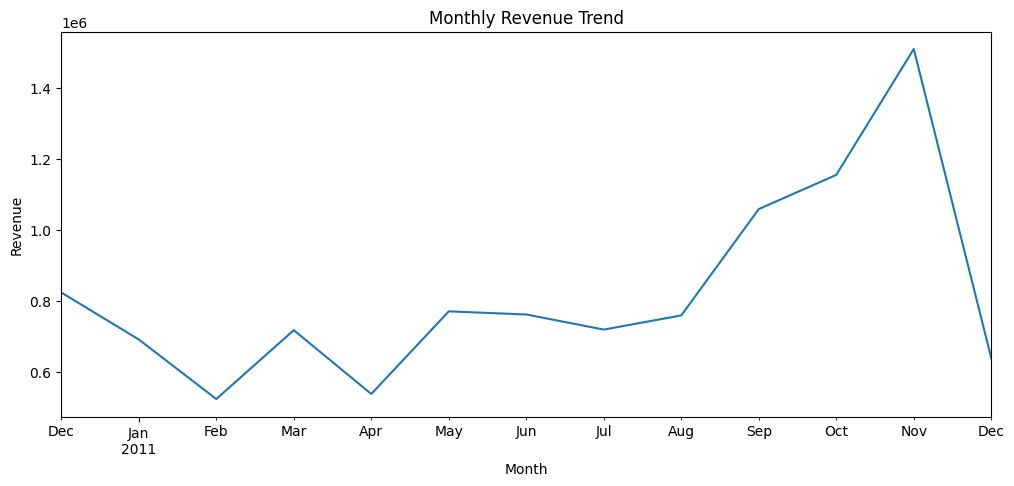

In [30]:
# Plot trend:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

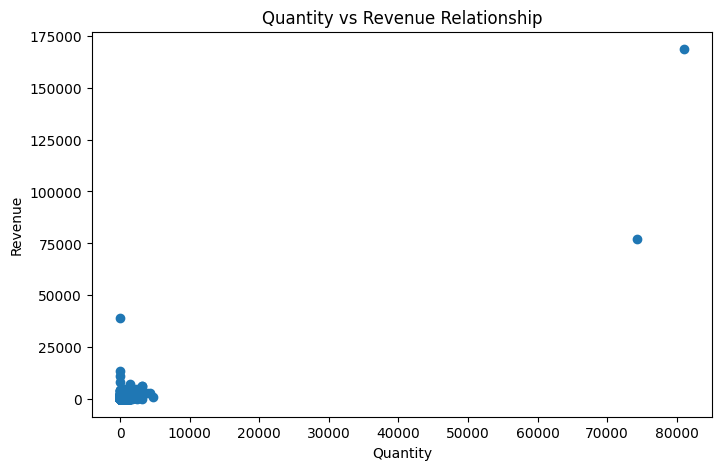

In [31]:
# STEP 9 – Quantity vs Revenue Relationship
plt.figure(figsize=(8,5))

plt.scatter(df["Quantity"], df["Revenue"])

plt.title("Quantity vs Revenue Relationship")

plt.xlabel("Quantity")

plt.ylabel("Revenue")

plt.show()

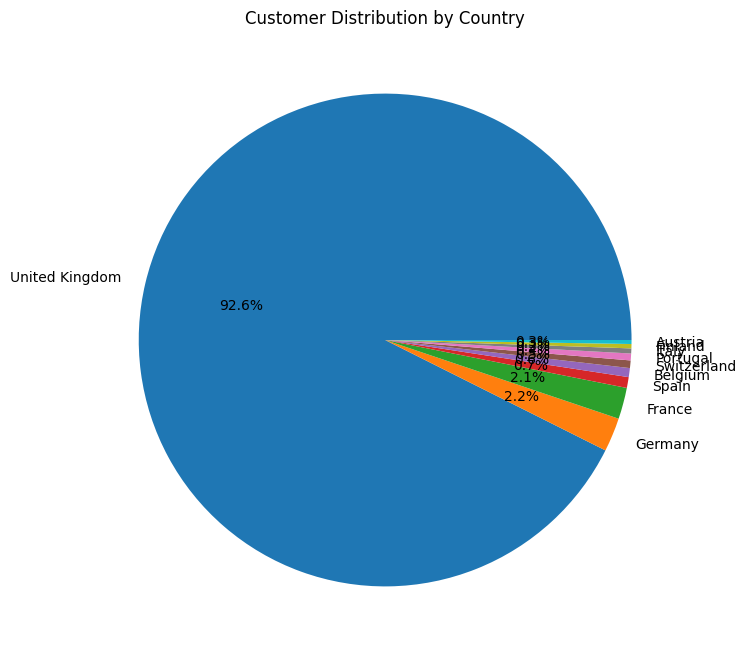

In [32]:
# STEP 10 – Customer Distribution by Country
customer_dist = df.groupby("Country")["CustomerID"].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,8))

customer_dist.plot(kind="pie", autopct="%1.1f%%")

plt.title("Customer Distribution by Country")

plt.ylabel("")

plt.show()

In [33]:
# Insight

# Shows where most customers belong.

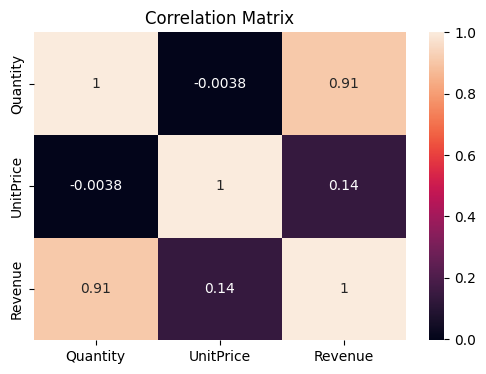

In [35]:
# STEP 11 – Correlation Heatmap
plt.figure(figsize=(6,4))

sns.heatmap(df[["Quantity","UnitPrice","Revenue"]].corr(),
            annot=True)

plt.title("Correlation Matrix")

plt.show()

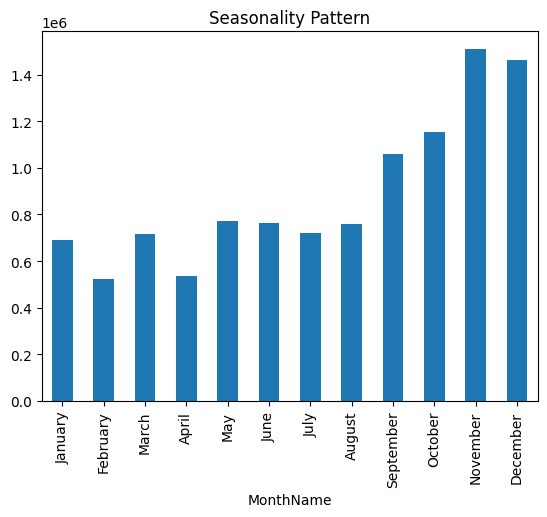

In [37]:
# Seasonal Pattern (Month-wise Comparison)
df["MonthName"] = df["InvoiceDate"].dt.month_name()

month_pattern = df.groupby("MonthName")["Revenue"].sum()

month_pattern = month_pattern.reindex([
"January","February","March","April","May","June",
"July","August","September","October","November","December"
])

month_pattern.plot(kind="bar")

plt.title("Seasonality Pattern")

plt.show()

In [38]:
# Average Order Value
avg_order_value = df.groupby("InvoiceNo")["Revenue"].sum().mean()

avg_order_value

np.float64(534.403033266533)

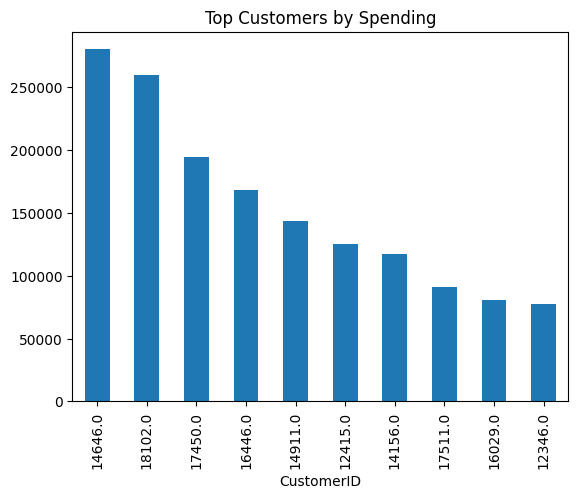

In [39]:
# High Value Customers
customer_value = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

customer_value.plot(kind="bar")

plt.title("Top Customers by Spending")

plt.show()

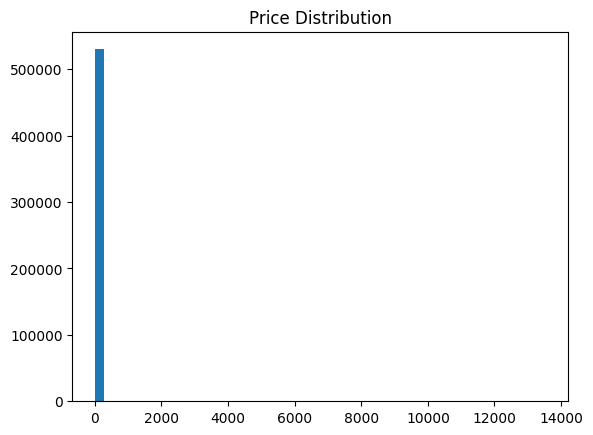

In [40]:
#Distribution of Unit Price
plt.hist(df["UnitPrice"], bins=50)

plt.title("Price Distribution")
#Concept:
#Price behaviour

plt.show()

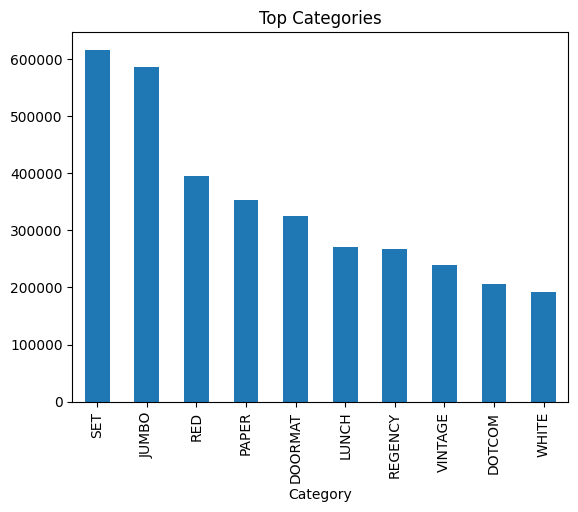

In [42]:
# Top Product Categories (based on keywords)
# Example grouping by keywords:
df["Category"] = df["Description"].str.split().str[0]

category_sales = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False).head(10)

category_sales.plot(kind="bar")

plt.title("Top Categories")

plt.show()

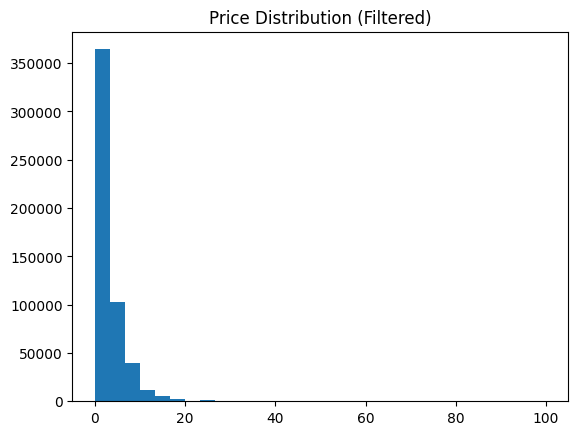

In [44]:
df_price = df[df["UnitPrice"] < 100]

plt.hist(df_price["UnitPrice"], bins=30)

plt.title("Price Distribution (Filtered)")

plt.show()

In [45]:
# update  it

In [46]:
# Storytelling Summary
# • few products generate most revenue
# • some countries have more customers
# • sales show seasonal pattern
# • high quantity does not always mean high revenue
# • few customers contribute large revenue
# • price impacts revenue